# BioE 242 Final Project: Drug Activity Prediction Using a Mixture-of-Experts Framework

**Main Question:** Does prediction of drug activity against kinase targets from SMILES strings benefit more from a Mixture-of-Experts architecture in a low-data regime or a high-data regime?

To investigate this question, Mixture-of-Experts (MoE) models will be trained and evaluated on datasets sized from $\sim$10,000 to the $\sim$50,000 SMILES to predict activity across 7 different kinase targets. The MoE framework consists of the following core, diverse model architectures:
1. XGBoost
2. Light Gradient Boosting Machine (Light GBM)
3. Random Forest
4. Directed Message Passing Neural Network (D-MPNN)
5. Graph Information Network (GIN)

A neural network gating mechanism will be trained on predictions (on unseen data) from trained versions of these models to predict per-expert weights based on the input. Together, the 5 experts and the gating network to route input/weigh experts form the MoE framework. 

Trained MoE models will be benchmarked against the 5 individual models and an ensemble model (with average weights).  

# Checkpoint 1: Data Preparation

## Import Packages and Libraries

In [1]:
import requests
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from descriptastorus.descriptors.DescriptorGenerator import MakeGenerator

## Download ChEMBL Kinase Activity Data

- **Data:** ChEMBL activity data against 7 kinase targets (EGFR, JAK2, p38 MAPK, BRAF, CDK2, ABL1, VEGFR2), which includes ~50k SMILES with activity values (pIC50) across all targets. The dataset has 3 columns in total: SMILES, target, and pIC50.

In [2]:
CHEMBL_URL = "https://www.ebi.ac.uk/chembl/api/data"

TARGETS = {
    "EGFR": "CHEMBL203",
    "JAK2": "CHEMBL2971",
    "p38_MAPK": "CHEMBL260",
    "BRAF": "CHEMBL5145",
    "CDK2": "CHEMBL301",
    "ABL1": "CHEMBL1862",
    "VEGFR2": "CHEMBL279"
}

MAX_WORKERS = 8

def fetch_page(url):
    try:
        r = requests.get(url)
        return r.json()
    except:
        return None

def fetch_all_activities(target_id):
    base = (
        f"{CHEMBL_URL}/activity.json?"
        f"target_chembl_id={target_id}"
        f"&standard_type=IC50"
        f"&limit=1000"
    )

    first = requests.get(base).json()
    activities = first["activities"]

    total = first["page_meta"]["total_count"]
    print(f"Total records: {total}")

    # Generate all page URLs
    offsets = list(range(1000, total, 1000))
    urls = [
        f"{base}&offset={offset}"
        for offset in offsets
    ]

    # Parallel fetch
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(fetch_page, url) for url in urls]

        for future in as_completed(futures):
            data = future.result()
            if data:
                activities.extend(data["activities"])

    return pd.DataFrame(activities)


def process_target(name, chembl_id):
    df = fetch_all_activities(chembl_id)

    # Filtering
    df = df[
        (df["standard_units"] == "nM") &
        (df["standard_value"].notnull()) &
        (df["assay_type"] == "B") &
        (df["canonical_smiles"].notnull())
    ]

    print(f"{name}: after filter = {len(df)}")

    # Convert values
    df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
    df = df.dropna(subset=["standard_value"])

    df["pIC50"] = -np.log10(df["standard_value"] * 1e-9)

    # Remove extreme values
    df = df[(df["pIC50"] > 3) & (df["pIC50"] < 12)]

    # Deduplicate
    df = df.groupby("canonical_smiles")["pIC50"].mean().reset_index()

    df["target"] = name
    df = df.rename(columns={"canonical_smiles": "smiles"})

    print(f"{name}: final = {len(df)}")

    return df

## Retrieve and Download ChEMBL Kinase activity dataset
all_dfs = []

for name, chembl_id in TARGETS.items():
    df = process_target(name, chembl_id)
    all_dfs.append(df)

kinase_df = pd.concat(all_dfs, ignore_index=True)
#kinase_df.to_csv("chembl_kinase_fast.csv", index=False)

Total records: 25758
EGFR: after filter = 22667
EGFR: final = 12858
Total records: 19236
JAK2: after filter = 18435
JAK2: final = 11504


/home/surya/anaconda3/envs/bioe_242/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Total records: 8159
p38_MAPK: after filter = 7070
p38_MAPK: final = 5500
Total records: 11014
BRAF: after filter = 10754
BRAF: final = 6581
Total records: 3637
CDK2: after filter = 3499
CDK2: final = 2766
Total records: 5290
ABL1: after filter = 5103
ABL1: final = 2692
Total records: 16870
VEGFR2: after filter = 15939
VEGFR2: final = 11553


In [5]:
# Dataset
kinase_df.head()

,smiles,pIC50,target
0,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(C(...,5.336488,EGFR
1,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc2c...,5.996539,EGFR
2,Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1...,8.397940,EGFR
3,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,7.207608,EGFR
4,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,8.420216,EGFR


## Data Processing: Determine Molecular Descriptors, Morgan Fingerprints, Murcko Scaffolds

- **Data processing steps:**
  + Bemis-Murcko scaffolds need to be computed for all the compounds. Scaffolds with too few compounds (e.g. < 5 examples) should be removed.
  + Molecular descriptors (using RDKit) and Morgan fingerprints must be computed.
  + Split the $\sim$50k samples into training and testing datasets using a scaffold-based split (which ensures that all compounds belonging to the same scaffold as assigned to the same data set). This should result in a roughtly 85%/15% split between the training and test sets ($\sim$45k samples in training set). We perform scaffold-based splits to prevent obtaining overly optimistic prediction accuracy on unseen data and to better measure generalizability to new structures.


In [4]:
class Featurizer:
    def __init__(self, fp_radius=3, fp_size=2048):
        self.fp_radius, self.fp_size = fp_radius, fp_size
        self._desc_gen = MakeGenerator(("RDKit2D",))
        self.descriptor_names = [x[0] for x in self._desc_gen.GetColumns()][1:]

    def smiles_to_fp(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(self.fp_size, dtype=np.int8)
        gen = rdFingerprintGenerator.GetMorganGenerator(radius=self.fp_radius, fpSize=self.fp_size)
        arr = np.zeros(self.fp_size, dtype=np.int8)
        DataStructs.ConvertToNumpyArray(gen.GetFingerprint(mol), arr)
        return arr

    def smiles_to_descriptors(self, smiles):
        result = self._desc_gen.process(smiles)
        n = len(self.descriptor_names)
        if result is None or result[0] == 0:
            return np.zeros(n, dtype=np.float64)
        arr = np.array(result[1:], dtype=np.float64)
        np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
        return arr

    def featurize_single(self, smiles):
        return np.concatenate([self.smiles_to_descriptors(smiles),
                                self.smiles_to_fp(smiles).astype(np.float64)])

    def get_feature_names_single(self):
        return list(self.descriptor_names) + [f"fp{i}" for i in range(self.fp_size)]


def add_murcko_scaffolds(df, smiles_col="smiles"):
    def _scaffold(smi):
        mol = Chem.MolFromSmiles(smi)
        if mol is None: return "PARSE_ERROR"
        return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
    df = df.copy()
    df["scaffold"] = df[smiles_col].apply(_scaffold)
    return df


In [ ]:
def process_dataset(df):
    """
    Featurize SMILES with RDKit descriptors + Morgan FPs, add Murcko scaffolds,
    and one-hot encode the target column.

    Dataframe columns : smiles, pIC50, target
    Output: dataframe with added columns for 200 RDKit descriptors, 2048 Morgan FP bits,
                    scaffold, scaffold_idx, per-target one-hot columns
    """
    featurizer = Featurizer(fp_radius=3, fp_size=2048)
    feat_arr = np.vstack([featurizer.featurize_single(s) for s in df["smiles"]])
    feat_df  = pd.DataFrame(feat_arr, columns=featurizer.get_feature_names_single(), index=df.index)

    out = add_murcko_scaffolds(df.copy(), smiles_col="smiles")
    out["scaffold_idx"] = out["scaffold"].map(
        {s: i for i, s in enumerate(out["scaffold"].unique())}
    )
    target_ohe = pd.get_dummies(out["target"], prefix="target")

    return pd.concat(
        [out[["smiles", "pIC50", "target", "scaffold", "scaffold_idx"]], feat_df, target_ohe],
        axis=1
    ).reset_index(drop=True)


kinase_raw = pd.read_csv("chembl_kinase_fast.csv")
kinase_processed_df = process_dataset(kinase_raw)
#kinase_processed_df.to_csv('chembl_kinase_processed.csv')

In [ ]:
kinase_processed_df = pd.read_csv('chembl_kinase_processed.csv', index_col=0)
kinase_processed_df.head()

In [ ]:
def split_dataset(df, split="scaffold", train_frac=0.85, seed=100):
      """
      Return train and test dataframes
      
      split="scaffold" : scaffolds assigned greedily to train until train_frac is met
      split="random"   : rows sampled at exactly train_frac
        
      """
      rng = np.random.default_rng(seed)
      if split == "scaffold":
          unique = np.array(df["scaffold"].unique().copy())
          rng.shuffle(unique)
          sizes = df.groupby("scaffold").size()
          chosen, count = set(), 0
          for s in unique[:-1]:
              if count / len(df) < train_frac and s is not np.NaN:
                  chosen.add(s)
                  count += sizes[s]
                  
          mask = df["scaffold"].isin(chosen).values
          
      else:
          idx  = rng.permutation(len(df))
          mask = np.zeros(len(df), dtype=bool)
          mask[idx[:int(round(len(df) * train_frac))]] = True
          
      return df[mask].reset_index(drop=True), df[~mask].reset_index(drop=True)


kinase_train_df, kinase_test_df = split_dataset(kinase_processed_df, split="scaffold")
print(f"Train: {len(kinase_train_df)}   Test: {len(kinase_test_df)}")


### Feature normalization and final train/test sets preparation

In [ ]:
# Select input features and normalize descriptor values

non_feature_columns = ["smiles", "pIC50", "target", "scaffold", "scaffold_idx"]                                                                                                                                                                                   
n_descriptors = 200 

feat_cols = [c for c in kinase_processed_df.columns if c not in non_feature_columns]           
                                                                                                                                                                                                                                                                
X_train = kinase_train_df[feat_cols].astype(np.float64).values
y_train = kinase_train_df["pIC50"].values
X_test  = kinase_test_df[feat_cols].astype(np.float64).values                                                                                                                                                                                                   
y_test  = kinase_test_df["pIC50"].values

# Sanitize before scaling — catches any inf/nan that survived featurization or CSV round-trip  
np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0, copy=False)                                                                                                                                                                                               
np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0, copy=False)    

scaler = StandardScaler()                                                                                                                                                                                                                                         
scaler.fit(X_train[:, :n_descriptors])                                                                                                                                                                                                                            
scaler.scale_[scaler.scale_ < 1e-6] = 1.0      

X_train_scaled = np.concatenate([scaler.transform(X_train[:, :n_descriptors]), X_train[:, n_descriptors:]], axis=1).astype(np.float32)                                                                                                                            
X_test_scaled  = np.concatenate([scaler.transform(X_test[:, :n_descriptors]),  X_test[:, n_descriptors:]],  axis=1).astype(np.float32)

# Checkpoint 2: Model Construction and Workflow

In [9]:
import numpy as np
import pandas as pd
import tempfile
import itertools

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from rdkit import Chem
from rdkit.Chem import rdchem

import torch
from torch_geometric.data import Data
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
import torch.optim as optim
from torch_geometric.loader import DataLoader


from chemprop import data as cdata, models as cmodels
from chemprop.nn import BondMessagePassing, MeanAggregation, RegressionFFN
import lightning.pytorch as pl

N_DESC = 200   # number of RDKit descriptor columns (first N_DESC features)
K_OOF  = 5    # inner OOF folds for honest expert predictions


In [10]:
# Atom and Bond features for GIN and D-MPNN

def one_hot(val, lst):
    return [int(val == x) for x in lst] + [int(val not in lst)]

def _atom_features(atom) -> list:
    ATOM_TYPES = [6, 7, 8, 16, 9, 17, 35, 53, 15]
    DEGREE_MAX = 6
    NUM_HS_MAX = 4
    HYBRID_TYPES = [
        rdchem.HybridizationType.SP,
        rdchem.HybridizationType.SP2,
        rdchem.HybridizationType.SP3,
        rdchem.HybridizationType.SP3D,
        rdchem.HybridizationType.SP3D2,
    ]

    anum = atom.GetAtomicNum()
    deg = min(atom.GetDegree(), DEGREE_MAX)
    nhs = min(atom.GetTotalNumHs(), NUM_HS_MAX)
    fc = max(-3, min(3, atom.GetFormalCharge())) / 3.0
    arom = int(atom.GetIsAromatic())
    ring = int(atom.IsInRing())
    hyb  = atom.GetHybridization()

    return (one_hot(anum, ATOM_TYPES)               
        + one_hot(deg, list(range(DEGREE_MAX + 1)))  
        + one_hot(nhs, list(range(NUM_HS_MAX + 1)))  
        + [fc, arom, ring]                    
        + one_hot(hyb, HYBRID_TYPES))  


def _bond_features(bond) -> list:
    BOND_TYPES = [
        rdchem.BondType.SINGLE,
        rdchem.BondType.DOUBLE,
        rdchem.BondType.TRIPLE,
        rdchem.BondType.AROMATIC,
    ]
    bt = bond.GetBondType()
    
    return (one_hot(bt, BOND_TYPES) + [int(bond.IsInRing())]) 


## D-MPNN Model Construction

In [ ]:
import math

class ChempropDMPNN:
    is_gnn    = True
    ATOM_FDIM = 33
    BOND_FDIM = 6

    def __init__(
        self,
        epochs: int = 50,
        batch_size: int = 64,
        hidden_size: int = 300,
        depth: int = 3,
        ffn_hidden: int = 300,
        ffn_layers: int = 2,
        lr: float = 1e-4,
        dropout: float = 0.0,
        seed: int = 42,
    ):
        self.epochs      = epochs
        self.batch_size  = batch_size
        self.hidden_size = hidden_size
        self.depth       = depth
        self.ffn_hidden  = ffn_hidden
        self.ffn_layers  = ffn_layers
        self.lr          = lr
        self.dropout     = dropout
        self.seed        = seed
        self.is_gnn      = True
        self._model       = None
        self._model_state = None

    def fit(self, smiles, y, sample_weight=None):
        torch.manual_seed(self.seed)

        y_arr   = np.asarray(y, dtype=np.float32)
        weights = np.asarray(sample_weight, dtype=np.float32) if sample_weight is not None else None

        datapoints = []
        for i, smi in enumerate(smiles):
            w = float(weights[i]) if weights is not None else 1.0
            datapoints.append(cdata.MoleculeDatapoint.from_smi(smi, np.array([y_arr[i]]), weight=w))

        dataset = cdata.MoleculeDataset(datapoints)
        loader  = cdata.build_dataloader(dataset, batch_size=self.batch_size, shuffle=True)

        mp  = BondMessagePassing(d_h=self.hidden_size, depth=self.depth)
        agg = MeanAggregation()
        ffn = RegressionFFN(
            n_tasks=1,
            input_dim=self.hidden_size,
            hidden_dim=self.ffn_hidden,
            n_layers=self.ffn_layers,
            dropout=self.dropout,
        )
        model = cmodels.MPNN(
            message_passing=mp,
            agg=agg,
            predictor=ffn,
            init_lr=self.lr,
            max_lr=self.lr * 10,
            final_lr=self.lr,
        )

        # Pre-compute max_steps so Lightning does not pre-scan the dataloader
        # (avoids slow first-pass hang on large datasets).
        n_batches = math.ceil(len(smiles) / self.batch_size)
        max_steps = self.epochs * n_batches

        with tempfile.TemporaryDirectory() as tmpdir:
            trainer = pl.Trainer(
                max_epochs=self.epochs,
                max_steps=max_steps,
                enable_progress_bar=False,
                enable_model_summary=False,
                logger=False,
                default_root_dir=tmpdir,
            )
            trainer.fit(model, loader)

        self._model       = model
        self._model_state = model.state_dict()
        return self

    def predict(self, smiles) -> np.ndarray:
        if self._model is None:
            raise RuntimeError("Call fit() before predict().")

        datapoints = [cdata.MoleculeDatapoint.from_smi(smi) for smi in smiles]
        dataset    = cdata.MoleculeDataset(datapoints)
        loader     = cdata.build_dataloader(dataset, batch_size=self.batch_size, shuffle=False)

        with tempfile.TemporaryDirectory() as tmpdir:
            trainer = pl.Trainer(
                enable_progress_bar=False,
                enable_model_summary=False,
                logger=False,
                default_root_dir=tmpdir,
            )
            raw = trainer.predict(self._model, loader)

        return np.concatenate([t.numpy() for t in raw]).ravel()

    def predict_uncertainty(self, smiles, T: int = 20) -> np.ndarray:
        if self._model is None:
            raise RuntimeError("Call fit() before predict_uncertainty().")

        import torch
        from chemprop import data as cdata

        datapoints = [cdata.MoleculeDatapoint.from_smi(smi) for smi in smiles]
        dataset    = cdata.MoleculeDataset(datapoints)
        loader     = cdata.build_dataloader(dataset, batch_size=self.batch_size, shuffle=False)

        dropout_states = {}
        for name, m in self._model.named_modules():
            if isinstance(m, torch.nn.Dropout):
                dropout_states[name] = m.training
                m.train()

        all_preds = []
        with torch.no_grad():
            for _ in range(T):
                preds_t = []
                for bi, batch in enumerate(loader):
                    try:
                        out = self._model.predict_step(batch, bi)
                    except Exception:
                        for name, m in self._model.named_modules():
                            if name in dropout_states:
                                m.training = dropout_states[name]
                        self._model.eval()
                        return np.zeros(len(smiles), dtype=np.float32)
                    if isinstance(out, torch.Tensor):
                        preds_t.append(out.detach().numpy().ravel())
                    else:
                        preds_t.append(
                            np.concatenate([t.detach().numpy().ravel() for t in out])
                        )
                all_preds.append(np.concatenate(preds_t))

        for name, m in self._model.named_modules():
            if name in dropout_states:
                m.training = dropout_states[name]
        self._model.eval()

        return np.std(np.stack(all_preds), axis=0).astype(np.float32)


## GIN Model Construction

In [ ]:
def _smiles_to_pyg(smiles_list, y_list=None):
    """Convert SMILES to PyG Data objects. Invalid SMILES become single-node graphs."""
    import torch
    from torch_geometric.data import Data

    N_FEAT = 33
    results = []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            x          = torch.zeros((1, N_FEAT), dtype=torch.float)
            edge_index = torch.zeros((2, 0), dtype=torch.long)
        else:
            x = torch.tensor(
                [_atom_features(a) for a in mol.GetAtoms()], dtype=torch.float
            )
            edges = []
            for bond in mol.GetBonds():
                u, v = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
                edges += [[u, v], [v, u]]
            edge_index = (
                torch.tensor(edges, dtype=torch.long).t().contiguous()
                if edges else torch.zeros((2, 0), dtype=torch.long)
            )
        d = Data(x=x, edge_index=edge_index)
        if y_list is not None:
            d.y = torch.tensor([float(y_list[i])], dtype=torch.float)
        results.append(d)
    return results


class _GINNet:
    @staticmethod
    def build(in_channels, hidden_channels, num_layers, dropout):
        import torch.nn as nn
        import torch.nn.functional as F
        from torch_geometric.nn import GINConv, global_mean_pool

        class _Net(nn.Module):
            def __init__(self):
                super().__init__()
                self.convs   = nn.ModuleList()
                self.bns     = nn.ModuleList()
                self.dropout = nn.Dropout(dropout)
                in_c = in_channels
                for _ in range(num_layers):
                    mlp = nn.Sequential(
                        nn.Linear(in_c, hidden_channels),
                        nn.BatchNorm1d(hidden_channels),
                        nn.ReLU(),
                        nn.Linear(hidden_channels, hidden_channels),
                    )
                    self.convs.append(GINConv(mlp))
                    self.bns.append(nn.BatchNorm1d(hidden_channels))
                    in_c = hidden_channels
                self.head = nn.Linear(hidden_channels, 1)

            def forward(self, x, edge_index, batch):
                for conv, bn in zip(self.convs, self.bns):
                    x = conv(x, edge_index)
                    x = bn(x)
                    x = F.relu(x)
                    x = self.dropout(x)
                x = global_mean_pool(x, batch)
                return self.head(x).squeeze(-1)

        return _Net()


class GIN:
    is_gnn = True
    ATOM_FDIM = 33

    def __init__(
        self,
        hidden_channels: int   = 256,
        num_layers:      int   = 4,
        dropout:         float = 0.3,
        epochs:          int   = 100,
        lr:              float = 1e-3,
        weight_decay:    float = 1e-4,
        batch_size:      int   = 64,
        seed:            int   = 42,
    ):
        self.hidden_channels = hidden_channels
        self.num_layers      = num_layers
        self.dropout         = dropout
        self.epochs          = epochs
        self.lr              = lr
        self.weight_decay    = weight_decay
        self.batch_size      = batch_size
        self.seed            = seed
        self.is_gnn          = True
        self._model  = None
        self._device = None

    def fit(self, smiles, y, sample_weight=None):
        torch.manual_seed(self.seed)
        self._device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        y_arr   = np.asarray(y, dtype=np.float32)
        weights = (
            np.asarray(sample_weight, dtype=np.float32)
            if sample_weight is not None
            else np.ones(len(y_arr), dtype=np.float32)
        )

        graph_list = _smiles_to_pyg(smiles, y_arr)
        for g, w in zip(graph_list, weights):
            g.weight = torch.tensor([w], dtype=torch.float)

        loader = DataLoader(graph_list, batch_size=self.batch_size, shuffle=True)

        self._model = _GINNet.build(
            self.ATOM_FDIM, self.hidden_channels, self.num_layers, self.dropout
        ).to(self._device)
        optimizer = optim.Adam(
            self._model.parameters(), lr=self.lr, weight_decay=self.weight_decay
        )

        self._model.train()
        for _ in range(self.epochs):
            for batch in loader:
                batch = batch.to(self._device)
                optimizer.zero_grad()
                out   = self._model(batch.x, batch.edge_index, batch.batch)
                w_b   = batch.weight.squeeze(-1)
                loss  = (w_b * (out - batch.y.squeeze(-1)) ** 2).mean()
                loss.backward()
                optimizer.step()

        self._model.eval()
        return self

    def predict(self, smiles) -> np.ndarray:
        if self._model is None:
            raise RuntimeError("Call fit() before predict().")

        loader = DataLoader(
            _smiles_to_pyg(smiles), batch_size=self.batch_size, shuffle=False
        )
        preds = []
        self._model.eval()
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(self._device)
                out   = self._model(batch.x, batch.edge_index, batch.batch)
                preds.append(out.cpu().numpy())

        return np.concatenate(preds)

    def predict_uncertainty(self, smiles, T: int = 20) -> np.ndarray:
        if self._model is None:
            raise RuntimeError("Call fit() before predict_uncertainty().")

        loader    = DataLoader(
            _smiles_to_pyg(smiles), batch_size=self.batch_size, shuffle=False
        )
        all_preds = []
        self._model.train()
        with torch.no_grad():
            for _ in range(T):
                preds_t = []
                for batch in loader:
                    batch = batch.to(self._device)
                    out   = self._model(batch.x, batch.edge_index, batch.batch)
                    preds_t.append(out.cpu().numpy())
                all_preds.append(np.concatenate(preds_t))

        self._model.eval()
        return np.std(np.stack(all_preds), axis=0).astype(np.float32)


## Gating Network Architecture

In [ ]:
import os

class GatingNetwork:
    def __init__(
        self,
        n_features: int,
        n_experts: int,
        hidden_sizes: list = None,
        lr: float = 1e-3,
        epochs: int = 300,
        weight_decay: float = 0.0,
        entropy_reg: float = 0.0,
        load_balancing: bool = False,
        oracle_reg: float = 0.01,
        temperature: float = 1.0,
    ):
        self.n_features     = n_features
        self.n_experts      = n_experts
        self.hidden_sizes   = list(hidden_sizes) if hidden_sizes is not None else [100, 80]
        self.lr             = lr
        self.epochs         = epochs
        self.weight_decay   = weight_decay
        self.entropy_reg    = entropy_reg
        self.load_balancing = load_balancing
        self.oracle_reg     = oracle_reg
        self.temperature    = max(temperature, 1e-6)
        self._scaler: StandardScaler = None
        self._net = None

    def _build(self):
        layers  = []
        in_size = self.n_features
        for h in self.hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        layers.append(nn.Linear(in_size, self.n_experts))
        return nn.Sequential(*layers)

    def fit(self, X_raw: np.ndarray, expert_preds: np.ndarray, y: np.ndarray):
        self._scaler = StandardScaler()
        X_scaled     = self._scaler.fit_transform(X_raw)
        self._net    = None
        self._train(X_scaled, expert_preds, y)

    def predict_weights(self, X_raw: np.ndarray, top_k: int = None):
        X_scaled = self._scaler.transform(X_raw)
        X_t      = torch.tensor(X_scaled, dtype=torch.float32)
        with torch.no_grad():
            logits  = self._net(X_t) / self.temperature
            weights = torch.softmax(logits, dim=1).numpy()

        if top_k is not None:
            mask     = np.zeros_like(weights)
            topk_idx = np.argpartition(weights, -top_k, axis=1)[:, -top_k:]
            np.put_along_axis(mask, topk_idx, 1.0, axis=1)
            weights  = weights * mask
            row_sums = weights.sum(axis=1, keepdims=True)
            weights  = weights / np.maximum(row_sums, 1e-8)

        return weights

    def _train(self, X_scaled: np.ndarray, expert_preds: np.ndarray, y: np.ndarray):
        X_t = torch.tensor(X_scaled,     dtype=torch.float32)
        E_t = torch.tensor(expert_preds, dtype=torch.float32)
        y_t = torch.tensor(y,            dtype=torch.float32)

        if self._net is None:
            self._net = self._build()

        K         = self.n_experts
        T         = self.temperature
        optimizer = optim.Adam(self._net.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        self._net.train()
        for _ in range(self.epochs):
            optimizer.zero_grad()
            logits  = self._net(X_t) / T
            weights = torch.softmax(logits, dim=1)
            preds   = (weights * E_t).sum(dim=1)
            loss    = nn.functional.mse_loss(preds, y_t)

            if self.entropy_reg > 0.0:
                entropy = -(weights * torch.log(weights + 1e-8)).sum(dim=1).mean()
                loss    = loss - self.entropy_reg * entropy

            if self.load_balancing:
                mean_w    = weights.mean(dim=0)
                load_loss = 0.01 * K * (mean_w ** 2).sum()
                loss      = loss + load_loss

            if self.oracle_reg > 0.0:
                with torch.no_grad():
                    errs     = (E_t - y_t.unsqueeze(1)) ** 2
                    oracle_w = torch.softmax(-errs, dim=1)
                oracle_loss = -(oracle_w * torch.log(weights + 1e-8)).sum(dim=1).mean()
                loss        = loss + self.oracle_reg * oracle_loss

            loss.backward()
            optimizer.step()

        self._net.eval()

    def save(self, model_dir: str):
        """Save gate MLP weights and internal scaler to model_dir."""
        import joblib
        os.makedirs(model_dir, exist_ok=True)
        torch.save(self._net.state_dict(), os.path.join(model_dir, "gate_net.pt"))
        joblib.dump(self._scaler, os.path.join(model_dir, "gate_scaler.joblib"))

    def load(self, model_dir: str):
        """Load gate MLP and scaler from model_dir (in-place)."""
        import joblib
        self._scaler = joblib.load(os.path.join(model_dir, "gate_scaler.joblib"))
        self._net    = self._build()
        state        = torch.load(
            os.path.join(model_dir, "gate_net.pt"), map_location="cpu", weights_only=True
        )
        self._net.load_state_dict(state)
        self._net.eval()
        return self


## Mixture of Experts Model 

In [ ]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

In [ ]:
import os, json, joblib

class MoE:
    EXPERT_NAMES = ["xgb", "rf", "lgbm", "chemprop", "gin"]

    def __init__(self, seed: int = 42):
        self.seed    = seed
        self.experts = None
        self.gate    = None
        self.scaler  = None

    @staticmethod
    def _make_experts(seed: int = 42):
        seeds = [seed, seed + 1, seed + 2, seed + 3, seed + 4]
        return [
            XGBRegressor(
                n_estimators=200, learning_rate=0.05, max_depth=6,
                subsample=0.8, colsample_bytree=0.8, n_jobs=-1, verbosity=0,
                random_state=seeds[0],
            ),
            RandomForestRegressor(
                n_estimators=200, max_depth=None, min_samples_leaf=3,
                n_jobs=-1, random_state=seeds[1],
            ),
            LGBMRegressor(
                n_estimators=200, learning_rate=0.05, max_depth=6,
                n_jobs=-1, verbose=-1, random_state=seeds[2],
            ),
            ChempropDMPNN(epochs=50, hidden_size=300, depth=3, seed=seeds[3]),
            GIN(hidden_channels=256, num_layers=4, dropout=0.3,
                weight_decay=1e-4, epochs=100, seed=seeds[4]),
        ]

    @staticmethod
    def _make_experts_from_config(config: dict, seed: int = 42):
        n_est = config.get("n_estimators", 200)
        lr    = config.get("learning_rate", 0.05)
        seeds = [seed, seed + 1, seed + 2, seed + 3, seed + 4]
        return [
            XGBRegressor(
                n_estimators=n_est, learning_rate=lr, max_depth=6,
                subsample=0.8, colsample_bytree=0.8, n_jobs=-1, verbosity=0,
                random_state=seeds[0],
            ),
            RandomForestRegressor(
                n_estimators=200, max_depth=None, min_samples_leaf=3,
                max_features=config.get("rf_max_features", 1.0),
                n_jobs=-1, random_state=seeds[1],
            ),
            LGBMRegressor(
                n_estimators=n_est, learning_rate=lr, max_depth=6,
                reg_lambda=config.get("lgbm_reg_lambda", 0.0),
                n_jobs=-1, verbose=-1, random_state=seeds[2],
            ),
            ChempropDMPNN(
                epochs=50, hidden_size=300, depth=3,
                dropout=config.get("dmpnn_dropout", 0.0), seed=seeds[3],
            ),
            GIN(
                hidden_channels=256,
                num_layers=config.get("gin_num_layers", 4),
                dropout=0.3, weight_decay=1e-4, epochs=100, seed=seeds[4],
            ),
        ]

    def train_experts_from_config(
        self, config: dict, X_scaled: np.ndarray, y: np.ndarray, smiles: list
    ) -> None:
        self.experts = self._make_experts_from_config(config, seed=self.seed)
        for name, expert in zip(self.EXPERT_NAMES, self.experts):
            print(f"  [MoE] Training {name}...", end=" ", flush=True)
            self._fit_one(expert, X_scaled, y, smiles)
            print("done")

    @staticmethod
    def _fit_one(expert, X_scaled: np.ndarray, y: np.ndarray, smiles: list,
                 sample_weight=None) -> None:
        if getattr(expert, "is_gnn", False):
            expert.fit(smiles, y, sample_weight=sample_weight)
        else:
            if sample_weight is not None:
                try:
                    expert.fit(X_scaled, y, sample_weight=sample_weight)
                except TypeError:
                    expert.fit(X_scaled, y)
            else:
                expert.fit(X_scaled, y)

    @staticmethod
    def _pred_one(expert, X_scaled: np.ndarray, smiles: list) -> np.ndarray:
        if getattr(expert, "is_gnn", False):
            return expert.predict(smiles)
        return expert.predict(X_scaled)

    @staticmethod
    def _uncertainty_one(expert, X_scaled: np.ndarray, smiles: list) -> np.ndarray:
        if getattr(expert, "is_gnn", False):
            return expert.predict_uncertainty(smiles).astype(np.float64)

        if isinstance(expert, RandomForestRegressor):
            tree_preds = np.column_stack([t.predict(X_scaled) for t in expert.estimators_])
            return tree_preds.std(axis=1)

        if XGBRegressor is not None and isinstance(expert, XGBRegressor):
            n_trees   = expert.n_estimators
            pred_full = expert.predict(X_scaled)
            dmat      = xgb.DMatrix(X_scaled)
            pred_half = expert.get_booster().predict(dmat, iteration_range=(0, max(1, n_trees // 2)))
            return np.abs(pred_full - pred_half)

        if LGBMRegressor is not None and isinstance(expert, LGBMRegressor):
            n_iter    = expert.n_estimators
            pred_full = expert.predict(X_scaled)
            pred_half = expert.predict(X_scaled, num_iteration=max(1, n_iter // 2))
            return np.abs(pred_full - pred_half)

        return np.zeros(len(X_scaled), dtype=np.float64)

    def _scale(self, X_raw: np.ndarray, fit: bool = False) -> np.ndarray:
        if fit:
            self.scaler = StandardScaler()
            desc_sc = self.scaler.fit_transform(X_raw[:, :N_DESC])
        else:
            desc_sc = self.scaler.transform(X_raw[:, :N_DESC])
        return np.concatenate([desc_sc, X_raw[:, N_DESC:]], axis=1)

    def train_experts(self, X_scaled: np.ndarray, y: np.ndarray, smiles: list):
        self.experts = self._make_experts(self.seed)
        for name, expert in zip(self.EXPERT_NAMES, self.experts):
            print(f"  [MoE] Training {name}...", end=" ", flush=True)
            self._fit_one(expert, X_scaled, y, smiles)
            print("done")

    def expert_predictions(self, X_scaled: np.ndarray, smiles: list):
        if self.experts is None:
            raise RuntimeError("Call train_experts() first.")
        preds = [self._pred_one(e, X_scaled, smiles) for e in self.experts]
        uncs  = [self._uncertainty_one(e, X_scaled, smiles) for e in self.experts]
        return np.column_stack(preds), np.column_stack(uncs)

    def train_gating_network(
        self,
        X_raw_desc: np.ndarray,
        E: np.ndarray,
        U: np.ndarray,
        y: np.ndarray,
        config: dict = None,
        gate_hidden_sizes: list = None,
        gate_lr: float = 1e-3,
        gate_epochs: int = 300,
        gate_oracle_reg: float = 0.01,
    ) -> None:
        if config is None:
            config = dict(weight_decay=0.0, entropy_reg=0.0, load_balancing=False, top_k=None)

        hidden_sizes = gate_hidden_sizes if gate_hidden_sizes is not None else [100, 80]
        X_gate = np.concatenate([X_raw_desc, E, U], axis=1)

        self.gate = GatingNetwork(
            n_features=X_gate.shape[1],
            n_experts=len(self.EXPERT_NAMES),
            hidden_sizes=hidden_sizes,
            lr=gate_lr,
            epochs=gate_epochs,
            weight_decay=config.get("weight_decay", 0.0),
            entropy_reg=config.get("entropy_reg", 0.0),
            load_balancing=config.get("load_balancing", False),
            oracle_reg=gate_oracle_reg,
        )
        self.gate.fit(X_gate, E, y)

    def evaluate(
        self,
        X_raw_desc: np.ndarray,
        X_scaled: np.ndarray,
        smiles: list,
        y_true: np.ndarray,
        top_k: int = None,
    ) -> dict:
        if self.experts is None or self.gate is None:
            raise RuntimeError("Train experts and gate before evaluating.")

        E, U      = self.expert_predictions(X_scaled, smiles)
        X_gate    = np.concatenate([X_raw_desc, E, U], axis=1)
        weights   = self.gate.predict_weights(X_gate, top_k=top_k)
        moe_preds = (weights * E).sum(axis=1)

        per_expert_rmse = [
            float(np.sqrt(mean_squared_error(y_true, E[:, k])))
            for k in range(E.shape[1])
        ]
        ensemble_preds = E.mean(axis=1)

        return dict(
            rmse=float(np.sqrt(mean_squared_error(y_true, moe_preds))),
            r2=float(r2_score(y_true, moe_preds)),
            per_expert_rmse=per_expert_rmse,
            ensemble_rmse=float(np.sqrt(mean_squared_error(y_true, ensemble_preds))),
        )

    def save(self, model_dir: str) -> None:
        """Save all experts, gate, descriptor scaler, and metadata to model_dir."""
        if self.experts is None or self.gate is None:
            raise RuntimeError("Train MoE before saving.")

        experts_dir = os.path.join(model_dir, "experts")
        os.makedirs(experts_dir, exist_ok=True)

        for name, expert in zip(self.EXPERT_NAMES[:3], self.experts[:3]):
            joblib.dump(expert, os.path.join(experts_dir, f"{name}.joblib"))

        chemprop_exp = self.experts[3]
        torch.save(chemprop_exp._model_state, os.path.join(experts_dir, "chemprop.pt"))
        gin_exp = self.experts[4]
        torch.save(gin_exp._model.state_dict(), os.path.join(experts_dir, "gin.pt"))

        joblib.dump(
            {
                "chemprop": {k: getattr(chemprop_exp, k) for k in
                             ["epochs", "batch_size", "hidden_size", "depth",
                              "ffn_hidden", "ffn_layers", "lr", "dropout", "seed"]},
                "gin": {k: getattr(gin_exp, k) for k in
                        ["hidden_channels", "num_layers", "dropout", "epochs",
                         "lr", "weight_decay", "batch_size", "seed"]},
            },
            os.path.join(experts_dir, "gnn_configs.joblib"),
        )

        if self.scaler is not None:
            joblib.dump(self.scaler, os.path.join(model_dir, "desc_scaler.joblib"))

        self.gate.save(model_dir)

        cfg = {
            "seed":              self.seed,
            "n_desc":            N_DESC,
            "expert_names":      self.EXPERT_NAMES,
            "gate_hidden_sizes": self.gate.hidden_sizes,
        }
        with open(os.path.join(model_dir, "config.json"), "w") as fh:
            json.dump(cfg, fh, indent=2)

    @classmethod
    def load(cls, model_dir: str) -> "MoE":
        """Reconstruct a fully trained MoE from a directory saved by save()."""
        with open(os.path.join(model_dir, "config.json")) as fh:
            cfg = json.load(fh)

        moe = cls(seed=cfg["seed"])

        experts_dir = os.path.join(model_dir, "experts")
        gnn_cfgs    = joblib.load(os.path.join(experts_dir, "gnn_configs.joblib"))

        tabular = [
            joblib.load(os.path.join(experts_dir, f"{n}.joblib"))
            for n in ["xgb", "rf", "lgbm"]
        ]

        cc = gnn_cfgs["chemprop"]
        chemprop_exp = ChempropDMPNN(**cc)
        mp  = BondMessagePassing(d_h=cc["hidden_size"], depth=cc["depth"])
        agg = MeanAggregation()
        ffn = RegressionFFN(
            n_tasks=1, input_dim=cc["hidden_size"],
            hidden_dim=cc["ffn_hidden"], n_layers=cc["ffn_layers"], dropout=cc["dropout"],
        )
        chemprop_model = cmodels.MPNN(
            message_passing=mp, agg=agg, predictor=ffn,
            init_lr=cc["lr"], max_lr=cc["lr"] * 10, final_lr=cc["lr"],
        )
        state = torch.load(
            os.path.join(experts_dir, "chemprop.pt"), map_location="cpu", weights_only=True
        )
        chemprop_model.load_state_dict(state)
        chemprop_model.eval()
        chemprop_exp._model       = chemprop_model
        chemprop_exp._model_state = state

        gc = gnn_cfgs["gin"]
        gin_exp         = GIN(**gc)
        gin_exp._device = torch.device("cpu")
        gin_net = _GINNet.build(GIN.ATOM_FDIM, gc["hidden_channels"], gc["num_layers"], gc["dropout"])
        gin_net.load_state_dict(
            torch.load(os.path.join(experts_dir, "gin.pt"), map_location="cpu", weights_only=True)
        )
        gin_net.eval()
        gin_exp._model = gin_net

        moe.experts = [*tabular, chemprop_exp, gin_exp]

        desc_scaler_path = os.path.join(model_dir, "desc_scaler.joblib")
        if os.path.exists(desc_scaler_path):
            moe.scaler = joblib.load(desc_scaler_path)

        gate = GatingNetwork(
            n_features=N_DESC + len(cls.EXPERT_NAMES) * 2,
            n_experts=len(cls.EXPERT_NAMES),
            hidden_sizes=cfg["gate_hidden_sizes"],
        )
        gate.load(model_dir)
        moe.gate = gate

        return moe


## Training Pipeline

In [ ]:
class Pipeline:
    """
    Single scaffold-based train/val split training pipeline.

    The pool (training) data is further split with K_OOF inner folds so that
    experts are trained on K_OOF-1 sections and the gating network is trained
    using predictions on the held-out section (OOF data), preventing leakage
    between expert training and gate training.
    """

    def __init__(
        self,
        seed: int = 42,
        val_frac: float = 0.15,
        val_split: str = "scaffold",
        verbose: bool = True,
        gate_hidden_sizes: list = None,
        gate_lr: float = 1e-3,
        gate_epochs: int = 300,
        gate_oracle_reg: float = 0.01,
        l2_regs: list = None,
        loss_configs: list = None,
        routing_schemes: list = None,
        n_folds: int = None,   # kept for backward compatibility, not used
    ):
        self.seed       = seed
        self.val_frac   = val_frac
        self.val_split  = val_split
        self.verbose    = verbose
        self.final_moe  = None

        self.gate_hidden_sizes = gate_hidden_sizes if gate_hidden_sizes is not None else [100, 80]
        self.gate_lr         = gate_lr
        self.gate_epochs     = gate_epochs
        self.gate_oracle_reg = gate_oracle_reg

        self.l2_regs = l2_regs if l2_regs is not None else [0.0, 0.001, 0.01, 0.1]
        self.loss_configs = loss_configs if loss_configs is not None else [
            dict(entropy_reg=0.0,  load_balancing=False),
            dict(entropy_reg=1e-4, load_balancing=False),
            dict(entropy_reg=1e-3, load_balancing=False),
            dict(entropy_reg=1e-2, load_balancing=False),
            dict(entropy_reg=0.1,  load_balancing=False),
            dict(entropy_reg=0.0,  load_balancing=True),
        ]
        self.routing_schemes = routing_schemes if routing_schemes is not None else [
            dict(top_k=None),
            dict(top_k=1),
            dict(top_k=2),
            dict(top_k=3),
        ]

    def _log(self, msg: str) -> None:
        if self.verbose:
            print(msg)

    def _scaffold_split(self, smiles: list, val_frac: float, seed: int):
        """
        Bemis-Murcko scaffold split. Returns (pool_idx, val_idx) as numpy arrays.
        Scaffolds are shuffled then greedily assigned to pool until (1-val_frac)
        is reached; remaining scaffolds go to val.
        """
        from rdkit import Chem
        from rdkit.Chem.Scaffolds import MurckoScaffold

        scaf_to_idx = {}
        for i, smi in enumerate(smiles):
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                scaf = ""
            else:
                scaf = Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
            scaf_to_idx.setdefault(scaf, []).append(i)

        rng    = np.random.default_rng(seed)
        unique = list(scaf_to_idx.keys())
        rng.shuffle(unique)

        n = len(smiles)
        train_frac = 1.0 - val_frac
        pool_idx, val_idx = [], []
        count = 0
        for scaf in unique[:-1]:
            if count / n < train_frac:
                pool_idx.extend(scaf_to_idx[scaf])
                count += len(scaf_to_idx[scaf])
            else:
                val_idx.extend(scaf_to_idx[scaf])
        val_idx.extend(scaf_to_idx[unique[-1]])

        return np.array(pool_idx), np.array(val_idx)

    def _run_inner_oof(
        self,
        X_pool_scaled: np.ndarray,
        y_pool: np.ndarray,
        smiles_pool: list,
        seed: int,
        expert_config: dict = None,
    ):
        """K_OOF-fold inner OOF on pool data."""
        n   = len(y_pool)
        rng = np.random.default_rng(seed)
        perm = rng.permutation(n)

        E_oof = np.zeros((n, len(MoE.EXPERT_NAMES)))
        U_oof = np.zeros((n, len(MoE.EXPERT_NAMES)))

        for k in range(K_OOF):
            val_start = round(n * k / K_OOF)
            val_end   = round(n * (k + 1) / K_OOF)
            iv_idx = perm[val_start:val_end]
            it_idx = np.concatenate([perm[:val_start], perm[val_end:]])

            X_it   = X_pool_scaled[it_idx]
            y_it   = y_pool[it_idx]
            smi_it = [smiles_pool[i] for i in it_idx]
            smi_iv = [smiles_pool[i] for i in iv_idx]

            self._log(f"    [OOF {k+1}/{K_OOF}] training experts ({len(it_idx):,} samples)...")
            experts_k = (
                MoE._make_experts_from_config(expert_config, seed=seed + k * 97 + 13)
                if expert_config is not None
                else MoE._make_experts(seed=seed + k * 97 + 13)
            )
            for name, exp in zip(MoE.EXPERT_NAMES, experts_k):
                self._log(f"      {name}...")
                MoE._fit_one(exp, X_it, y_it, smi_it)

            for j, exp in enumerate(experts_k):
                E_oof[iv_idx, j] = MoE._pred_one(exp, X_pool_scaled[iv_idx], smi_iv)
                U_oof[iv_idx, j] = MoE._uncertainty_one(exp, X_pool_scaled[iv_idx], smi_iv)

        return E_oof, U_oof

    def _eval_val(
        self,
        gate: GatingNetwork,
        X_val_gate: np.ndarray,
        E_val: np.ndarray,
        y_val: np.ndarray,
        top_k: int = None,
    ):
        """Return (rmse, r2) for the validation set given a trained gate."""
        w     = gate.predict_weights(X_val_gate, top_k=top_k)
        preds = (w * E_val).sum(axis=1)
        rmse  = float(np.sqrt(mean_squared_error(y_val, preds)))
        r2    = float(r2_score(y_val, preds))
        return rmse, r2

    def run(self, X_raw: np.ndarray, y: np.ndarray, smiles: list):
        """
        Single scaffold-based train/val split with gate hyperparameter search.
        The final MoE is trained on the full dataset using the best gate config found.
        """
        np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0, copy=False)

        pool_idx, val_idx = self._scaffold_split(smiles, self.val_frac, self.seed)
        self._log(
            f"[Split] pool={len(pool_idx):,}  val={len(val_idx):,}  "
            f"(scaffold split, val_frac={self.val_frac})"
        )

        X_pool_raw = X_raw[pool_idx];  y_pool = y[pool_idx]
        smi_pool   = [smiles[i] for i in pool_idx]
        X_val_raw  = X_raw[val_idx];   y_val  = y[val_idx]
        smi_val    = [smiles[i] for i in val_idx]

        scaler        = StandardScaler()
        desc_sc       = scaler.fit_transform(X_pool_raw[:, :N_DESC].astype(np.float64))
        X_pool_scaled = np.concatenate([desc_sc, X_pool_raw[:, N_DESC:]], axis=1)
        desc_val      = scaler.transform(X_val_raw[:, :N_DESC].astype(np.float64))
        X_val_scaled  = np.concatenate([desc_val, X_val_raw[:, N_DESC:]], axis=1)

        self._log("  Running inner OOF on pool...")
        E_oof, U_oof = self._run_inner_oof(X_pool_scaled, y_pool, smi_pool, seed=self.seed)

        self._log("  Training pool experts (for val prediction)...")
        pool_moe        = MoE(seed=self.seed + 7)
        pool_moe.scaler = scaler
        pool_moe.train_experts(X_pool_scaled, y_pool, smi_pool)
        E_val, U_val = pool_moe.expert_predictions(X_val_scaled, smi_val)

        X_gate_pool = np.concatenate([X_pool_raw[:, :N_DESC], E_oof, U_oof], axis=1)
        X_gate_val  = np.concatenate([X_val_raw[:, :N_DESC],  E_val, U_val], axis=1)
        self._log(f"  Gate input shape: {X_gate_pool.shape} (pool), {X_gate_val.shape} (val)")

        hyperparam_grid = [
            dict(weight_decay=l2, **loss, **routing)
            for l2, loss, routing in itertools.product(
                self.l2_regs, self.loss_configs, self.routing_schemes
            )
        ]
        self._log(f"  Searching {len(hyperparam_grid)} gate configs...")
        best_rmse, best_r2, best_config = float("inf"), float("-inf"), None

        for cfg in hyperparam_grid:
            gate = GatingNetwork(
                n_features=X_gate_pool.shape[1],
                n_experts=len(MoE.EXPERT_NAMES),
                hidden_sizes=self.gate_hidden_sizes,
                lr=self.gate_lr,
                epochs=self.gate_epochs,
                weight_decay=cfg["weight_decay"],
                entropy_reg=cfg["entropy_reg"],
                load_balancing=cfg["load_balancing"],
                oracle_reg=self.gate_oracle_reg,
            )
            gate.fit(X_gate_pool, E_oof, y_pool)
            rmse, r2 = self._eval_val(gate, X_gate_val, E_val, y_val, top_k=cfg["top_k"])
            if rmse < best_rmse:
                best_rmse, best_r2, best_config = rmse, r2, cfg

        self._log(f"  Best val RMSE={best_rmse:.4f}  R²={best_r2:.4f}")
        self._log(f"  Best config: {best_config}")

        self._log("\n[Final MoE] Training on full dataset...")
        full_scaler  = StandardScaler()
        desc_all     = full_scaler.fit_transform(X_raw[:, :N_DESC].astype(np.float64))
        X_all_scaled = np.concatenate([desc_all, X_raw[:, N_DESC:]], axis=1)

        self._log("  Running OOF on full data...")
        E_oof_full, U_oof_full = self._run_inner_oof(
            X_all_scaled, y, smiles, seed=self.seed + 9999
        )

        self._log("  Training final experts on full data...")
        self.final_moe        = MoE(seed=self.seed)
        self.final_moe.scaler = full_scaler
        self.final_moe.train_experts(X_all_scaled, y, smiles)

        _, U_full   = self.final_moe.expert_predictions(X_all_scaled, smiles)
        X_gate_full = np.concatenate([X_raw[:, :N_DESC], E_oof_full, U_full], axis=1)

        self._log("  Training final gate...")
        self.final_moe.gate = GatingNetwork(
            n_features=X_gate_full.shape[1],
            n_experts=len(MoE.EXPERT_NAMES),
            hidden_sizes=self.gate_hidden_sizes,
            lr=self.gate_lr,
            epochs=self.gate_epochs,
            weight_decay=best_config.get("weight_decay", 0.0),
            entropy_reg=best_config.get("entropy_reg", 0.0),
            load_balancing=best_config.get("load_balancing", False),
            oracle_reg=self.gate_oracle_reg,
        )
        self.final_moe.gate.fit(X_gate_full, E_oof_full, y)
        self._log("[Final MoE] Done.")

        return dict(
            mean_rmse=float(best_rmse),
            std_rmse=0.0,
            mean_r2=float(best_r2),
            std_r2=0.0,
            fold_results=[dict(fold=1, val_rmse=best_rmse, val_r2=best_r2, best_config=best_config)],
            best_config=best_config,
            final_moe=self.final_moe,
        )

    def run_expert_gate_grid_search(
        self,
        X_raw: np.ndarray,
        y: np.ndarray,
        smiles: list,
        expert_configs: list = None,
        oracle_regs: list = None,
    ) -> dict:
        """
        Joint grid search over expert hyperparameters and gate hyperparameters,
        evaluated on a single scaffold-based train/val split.
        """
        if expert_configs is None:
            expert_configs = []
        if oracle_regs is None:
            oracle_regs = [0.0, 0.01, 0.1]

        np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0, copy=False)

        pool_idx, val_idx = self._scaffold_split(smiles, self.val_frac, self.seed)
        self._log(
            f"[Split] pool={len(pool_idx):,}  val={len(val_idx):,}  "
            f"(scaffold split, val_frac={self.val_frac})"
        )

        X_pool_raw = X_raw[pool_idx];  y_pool = y[pool_idx]
        smi_pool   = [smiles[i] for i in pool_idx]
        X_val_raw  = X_raw[val_idx];   y_val  = y[val_idx]
        smi_val    = [smiles[i] for i in val_idx]

        scaler        = StandardScaler()
        desc_sc       = scaler.fit_transform(X_pool_raw[:, :N_DESC].astype(np.float64))
        X_pool_scaled = np.concatenate([desc_sc, X_pool_raw[:, N_DESC:]], axis=1)
        desc_val      = scaler.transform(X_val_raw[:, :N_DESC].astype(np.float64))
        X_val_scaled  = np.concatenate([desc_val, X_val_raw[:, N_DESC:]], axis=1)

        gate_grid = [
            dict(weight_decay=l2, oracle_reg=oreg, **loss, **routing)
            for l2, oreg, loss, routing in itertools.product(
                self.l2_regs, oracle_regs, self.loss_configs, self.routing_schemes
            )
        ]

        n_exp  = len(expert_configs)
        n_gate = len(gate_grid)
        self._log(
            f"[run_expert_gate_grid_search] "
            f"{n_exp} expert configs x {n_gate} gate configs = {n_exp * n_gate:,} gate evals"
        )

        rmse_matrix = np.full((n_exp, n_gate), np.inf)
        r2_matrix   = np.full((n_exp, n_gate), -np.inf)

        for ecfg_idx, ecfg in enumerate(expert_configs):
            self._log(f"\n  [Expert config {ecfg_idx+1}/{n_exp}] {ecfg}")

            self._log("    Running inner OOF...")
            oof_seed = self.seed + ecfg_idx * 100
            E_oof, U_oof = self._run_inner_oof(
                X_pool_scaled, y_pool, smi_pool, seed=oof_seed, expert_config=ecfg
            )

            self._log("    Training pool experts (for val prediction)...")
            pool_moe        = MoE(seed=self.seed + ecfg_idx * 50 + 7)
            pool_moe.scaler = scaler
            pool_moe.train_experts_from_config(ecfg, X_pool_scaled, y_pool, smi_pool)
            E_val, U_val = pool_moe.expert_predictions(X_val_scaled, smi_val)

            X_gate_pool = np.concatenate([X_pool_raw[:, :N_DESC], E_oof, U_oof], axis=1)
            X_gate_val  = np.concatenate([X_val_raw[:, :N_DESC],  E_val, U_val], axis=1)

            self._log(f"    Evaluating {n_gate} gate configs...")
            for gcfg_idx, gcfg in enumerate(gate_grid):
                gate = GatingNetwork(
                    n_features=X_gate_pool.shape[1],
                    n_experts=len(MoE.EXPERT_NAMES),
                    hidden_sizes=self.gate_hidden_sizes,
                    lr=self.gate_lr,
                    epochs=self.gate_epochs,
                    weight_decay=gcfg["weight_decay"],
                    entropy_reg=gcfg["entropy_reg"],
                    load_balancing=gcfg["load_balancing"],
                    oracle_reg=gcfg["oracle_reg"],
                )
                gate.fit(X_gate_pool, E_oof, y_pool)
                rmse, r2 = self._eval_val(
                    gate, X_gate_val, E_val, y_val, top_k=gcfg.get("top_k")
                )
                rmse_matrix[ecfg_idx, gcfg_idx] = rmse
                r2_matrix[ecfg_idx,   gcfg_idx] = r2

        best_flat = int(np.argmin(rmse_matrix))
        best_ecfg_idx, best_gcfg_idx = np.unravel_index(best_flat, rmse_matrix.shape)

        best_expert_config = expert_configs[best_ecfg_idx]
        best_gate_config   = gate_grid[best_gcfg_idx]
        best_combined      = {**best_expert_config, **best_gate_config}
        best_rmse = float(rmse_matrix[best_ecfg_idx, best_gcfg_idx])
        best_r2   = float(r2_matrix[best_ecfg_idx,   best_gcfg_idx])

        self._log("\n[Grid Search Summary]")
        self._log(f"  Best val RMSE : {best_rmse:.4f}")
        self._log(f"  Best val R²   : {best_r2:.4f}")
        self._log(f"  Best expert config (idx {best_ecfg_idx}): {best_expert_config}")
        self._log(f"  Best gate config   (idx {best_gcfg_idx}): {best_gate_config}")

        self._log("\n[Final MoE] Training on full dataset...")
        full_scaler  = StandardScaler()
        desc_all     = full_scaler.fit_transform(X_raw[:, :N_DESC].astype(np.float64))
        X_all_scaled = np.concatenate([desc_all, X_raw[:, N_DESC:]], axis=1)

        self._log("  Running OOF on full data...")
        E_oof_full, U_oof_full = self._run_inner_oof(
            X_all_scaled, y, smiles, seed=self.seed + 9999, expert_config=best_expert_config
        )

        self._log("  Training final experts on full data...")
        self.final_moe        = MoE(seed=self.seed)
        self.final_moe.scaler = full_scaler
        self.final_moe.train_experts_from_config(best_expert_config, X_all_scaled, y, smiles)

        _, U_full   = self.final_moe.expert_predictions(X_all_scaled, smiles)
        X_gate_full = np.concatenate([X_raw[:, :N_DESC], E_oof_full, U_full], axis=1)

        self._log("  Training final gate...")
        self.final_moe.gate = GatingNetwork(
            n_features=X_gate_full.shape[1],
            n_experts=len(MoE.EXPERT_NAMES),
            hidden_sizes=self.gate_hidden_sizes,
            lr=self.gate_lr,
            epochs=self.gate_epochs,
            weight_decay=best_gate_config.get("weight_decay", 0.0),
            entropy_reg=best_gate_config.get("entropy_reg", 0.0),
            load_balancing=best_gate_config.get("load_balancing", False),
            oracle_reg=best_gate_config.get("oracle_reg", self.gate_oracle_reg),
        )
        self.final_moe.gate.fit(X_gate_full, E_oof_full, y)
        self._log("[Final MoE] Done.")

        return dict(
            mean_rmse=best_rmse,
            std_rmse=0.0,
            mean_r2=best_r2,
            std_r2=0.0,
            fold_results=[dict(fold=1, val_rmse=best_rmse, val_r2=best_r2, best_config=best_combined)],
            best_config=best_combined,
            final_moe=self.final_moe,
        )


# Checkpoint 3 - Regularization Strategies and Hyperparameter Tuning

## Regularization Strategies and Hyperparameters

The `run_expert_gate_grid_search` pipeline jointly searches two axes: **expert model configurations** and **gating network hyperparameters**. For each combination, expert predictions on "out-of-fold" (OOF), i.e. unseen data, are used to train and evaluate the gating network, which prevents data leakage.

---

### Expert Model Hyperparameters

| Parameter | Models affected | What it controls | Values searched |
|---|---|---|---|
| `n_estimators` + `learning_rate` | XGBoost, LightGBM | Ensemble size and shrinkage; more trees + lower lr = better generalization at cost of speed | (200, 0.05) vs (500, 0.02) |
| `lgbm_reg_lambda` | LightGBM | L2 regularization on leaf weights; LightGBM defaults to 0 unlike XGBoost | 0.0 vs 1.0 |
| `rf_max_features` | Random Forest | Feature subsetting per split; "sqrt" adds tree diversity, improving uncertainty estimates | 1.0 (all) vs "sqrt" |
| `dmpnn_dropout` | Chemprop (D-MPNN) | Dropout in the FFN readout; also enables MC-Dropout uncertainty for the gate | 0.0 vs 0.2 |
| `gin_num_layers` | GIN | Number of message-passing layers; fewer layers reduce over-smoothing on large molecules | 3 vs 4 |

The 4 expert configs are the corners of a 2×2 grid: **tabular-regularised** (B, D) vs. baseline (A, C), and **GNN-regularised** (C, D) vs. baseline (A, B).

---

### Gating Network Hyperparameters

| Parameter | What it controls | Values searched |
|---|---|---|
| `weight_decay` (L2) | L2 penalty on gate MLP weights; prevents the gate from over-fitting to expert predictions | [0.0, 0.001, 0.01, 0.1] |
| `oracle_reg` | This controls cross-entropy loss pushing gate weights toward the per-sample best expert; the most impactful gating network hyperparameter | [0.0, 0.01, 0.1] |
| `entropy_reg` | Entropy "bonus" on routing weights; higher values force more uniform routing (soft ensemble), lower values allow concentration on one expert | [0.0, 1e-4, 1e-3, 1e-2, 0.1] |
| `load_balancing` | Load-balancing loss: penalizes collapsed routing where most samples go to one expert | False, True |
| `top_k` (routing) | Sparse routing: zeroes out all but the top-k weights per sample; `None` = soft (all experts weighted), 1–3 = hard selection | None, 1, 2, 3 |

**Entropy regularization** and **load balancing** serve opposite ends: entropy encourages diversity (all experts used), while load balancing prevents "expert collapse" where all the weight is assigned to one expert. The right tradeoff depends on how heterogeneous the experts are at learning from the data.

In [2]:
# Hyperparameter dictionary for run_expert_gate_grid_search

HP = dict(
    seed = 87,
    n_folds = 4,

    # Gate architecture & training (fixed, not searched)
    gate_hidden_sizes = [100, 80],
    gate_lr = 1e-3,
    gate_epochs = 300, 
    gate_oracle_reg = 0.01, 

    # Gate L2 regularization 
    # Weight decay on gate MLP weights.
    l2_regs = [0.0, 0.001, 0.01, 0.1],

    # Cross-entropy loss pushing routing weights toward the per-sample best expert.
    # 0.0 = gate is purely MSE-driven; 0.1 = strong oracle guidance.
    oracle_regs = [0.0, 0.01, 0.1],

    # Gate grid: entropy regularization and load balancing 
    # entropy_reg > 0: bonus for spreading weight across experts (near-uniform routing).
    # load_balancing = True: Switch-Transformer penalty for routing collapse.
    loss_configs = [
        dict(entropy_reg=0.0,  load_balancing=False),   # baseline
        dict(entropy_reg=1e-4, load_balancing=False),   # very mild entropy
        dict(entropy_reg=1e-3, load_balancing=False),   # mild entropy
        dict(entropy_reg=1e-2, load_balancing=False),   # moderate entropy
        dict(entropy_reg=0.1,  load_balancing=False),   # strong: near-uniform routing
        dict(entropy_reg=0.0,  load_balancing=True),    # load balancing instead
    ],

    # Gate routing scheme 
    # top_k=None: soft routing (all experts contribute).
    # top_k=1/2/3: sparse routing (only top-k experts used per sample).
    routing_schemes = [
        dict(top_k=None),
        dict(top_k=1),
        dict(top_k=2),
        dict(top_k=3),
    ],

    # Expert model configurations
    # 4 configs = corners of (tabular-regularised) x (GNN-regularised).
    expert_configs = [
        # A — baseline: matches _make_experts() defaults
        dict(n_estimators=200, learning_rate=0.05, lgbm_reg_lambda=0.0,
             rf_max_features=1.0,    dmpnn_dropout=0.0, gin_num_layers=4),
        # B — stronger tabular: more trees + lower lr, LightGBM L2, RF feature diversity
        dict(n_estimators=500, learning_rate=0.02, lgbm_reg_lambda=1.0,
             rf_max_features="sqrt", dmpnn_dropout=0.0, gin_num_layers=4),
        # C — GNN regularization: DMPNN dropout, shallower GIN (less over-smoothing)
        dict(n_estimators=200, learning_rate=0.05, lgbm_reg_lambda=0.0,
             rf_max_features=1.0,    dmpnn_dropout=0.2, gin_num_layers=3),
        # D — all tuned: combines B tabular + C GNN regularization
        dict(n_estimators=500, learning_rate=0.02, lgbm_reg_lambda=1.0,
             rf_max_features="sqrt", dmpnn_dropout=0.2, gin_num_layers=3),
    ],
)

print(f"Gate configs per expert config: "
      f"{len(HP['l2_regs'])} l2 x {len(HP['oracle_regs'])} oracle x "
      f"{len(HP['loss_configs'])} loss x {len(HP['routing_schemes'])} routing = "
      f"{len(HP['l2_regs'])*len(HP['oracle_regs'])*len(HP['loss_configs'])*len(HP['routing_schemes'])} configs")
print(f"Expert configs: {len(HP['expert_configs'])}")
print(f"Total gate evals: {len(HP['l2_regs'])*len(HP['oracle_regs'])*len(HP['loss_configs'])*len(HP['routing_schemes'])*len(HP['expert_configs'])*HP['n_folds']:,}")


Gate configs per expert config: 4 l2 x 3 oracle x 6 loss x 4 routing = 288 configs
Expert configs: 4
Total gate evals: 4,608


# Checkpoint 4 - Production Mode

Primary deliverables after a "production run": 
1. **Low-data vs high-data regime analysis:** compare MoE performance on 10K dataset vs 50K datset. Compute $\Delta$ in RMSE/$R^2$ for MoEs between these two sized datasets and create a bar graph comparing the $\Delta$ values across: MoE, each individual expert model, equal-weight ensemble.
2. **Best MoE configuration:** record best hyperparameters and training setup for gating network, namely the best routing scheme and the best form of additional regularization, e.g. entropy regularization and load-balancing loss. 
3. **Average weights per scaffold bar graph/side-by-side box plots:** this graph will display what the expert weight distribution looks like for the top 10 most popular scaffolds. 

In [ ]:
import os, json
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
def moe_production_pipeline(path, HP=HP, verbose=True):
    """
    --- Main Steps --- 
    1. Sample a 10k subset of training data (each SMILES proportional to scaffold size) and run the full
       expert-plus-gate grid search on both subsets. Evaluate all model types on the test
       set and plot change in RMSE and R² between models trained on the two datasets. 
    2. Save the best gate configuration for each data regime. 
    3. Plot per-scaffold expert weight distributions for the top-10 most frequent
       scaffolds in the test set, showing mean bars with box-plot overlays.

    Parameters:
        path : str
            Output directory. Created if it does not exist.
        HP : dict
            Hyperparameter dictionary.
        verbose : bool
            Print progress if True (default)

    Returns:
        dict: low_data_metrics, full_data_metrics, delta_rmse, delta_r2,
                    best_config_low, best_config_full
    """

    os.makedirs(path, exist_ok=True)

    EXPERT_NAMES  = MoE.EXPERT_NAMES # ["xgb","rf","lgbm","chemprop","gin"]
    MODEL_LABELS  = ["MoE", "XGB", "RF", "LGBM", "Chemprop", "GIN", "Ensemble"]
    NON_FEAT_COLS = ["smiles", "pIC50", "target", "scaffold", "scaffold_idx"]

    # Helper methods 
    
    def _log(msg):
        if verbose:
            print(msg, flush=True)

    def _sample_scaffold_proportional(train_df, n, seed):
        """
        Sample n rows from train_df so each scaffold contributes approximately
        the same fraction as it does in the full training set.
        """
        rng = np.random.default_rng(seed)
        scaffold_sizes = train_df.groupby("scaffold").size()
        total = len(train_df)
        scaffolds = list(scaffold_sizes.index)

        # Proportional allocation with rounding correction
        allocated = {s: max(0, round(n * scaffold_sizes[s] / total)) for s in scaffolds}
        diff = n - sum(allocated.values())
        if diff != 0:
            sign = int(np.sign(diff))
            sorted_scafs = sorted(scaffolds, key=lambda s: scaffold_sizes[s], reverse=(sign > 0))
            for s in sorted_scafs:
                if diff == 0:
                    break
                allocated[s] += sign
                diff -= sign

        sampled_idx = []
        for scaf, k in allocated.items():
            k = min(int(k), scaffold_sizes[scaf])
            if k <= 0:
                continue
            scaf_row_idx = train_df.index[train_df["scaffold"] == scaf].tolist()
            chosen = rng.choice(scaf_row_idx, size=k, replace=False)
            sampled_idx.extend(chosen.tolist())

        return train_df.loc[sampled_idx].reset_index(drop=True)

    def _build_xy(df):
        """Extract X (numpy, float64, sanitized), y, smiles from a kinase DataFrame."""
        fc = [c for c in df.columns if c not in NON_FEAT_COLS]
        X = df[fc].astype(np.float64).values
        np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
        return X, df["pIC50"].values, df["smiles"].tolist()

    def _run_pipeline(X_raw, y, smiles, label):
        """Instantiate a Pipeline and run the full expert plus gate grid search."""
        _log(f"\n{'='*62}\n  Pipeline: {label}  ({len(y):,} samples)\n{'='*62}")
        pipe = Pipeline(
            seed=HP["seed"],
            n_folds=HP["n_folds"],
            gate_hidden_sizes=HP["gate_hidden_sizes"],
            gate_lr=HP["gate_lr"],
            gate_epochs=HP["gate_epochs"],
            gate_oracle_reg=HP["gate_oracle_reg"],
            l2_regs=HP["l2_regs"],
            loss_configs=HP["loss_configs"],
            routing_schemes=HP["routing_schemes"],
            verbose=verbose,
        )
        results = pipe.run_expert_gate_grid_search(
            X_raw, y, smiles,
            expert_configs=HP["expert_configs"],
            oracle_regs=HP["oracle_regs"],
        )
        return pipe, results

    def _evaluate_on_test(final_moe, best_config, X_test_raw, y_test_arr, smiles_test_lst):
        top_k = best_config.get("top_k", None)

        X_desc = X_test_raw[:, :N_DESC].astype(np.float64)
        X_scaled = np.concatenate(
            [final_moe.scaler.transform(X_desc),
             X_test_raw[:, N_DESC:].astype(np.float64)], axis=1
        )

        E, U = final_moe.expert_predictions(X_scaled, smiles_test_lst)
        X_gate = np.concatenate([X_desc, E, U], axis=1)
        weights  = final_moe.gate.predict_weights(X_gate, top_k=top_k)
        moe_pred = (weights * E).sum(axis=1)
        ens_pred = E.mean(axis=1)

        metrics = {
            "moe_rmse": float(np.sqrt(mean_squared_error(y_test_arr, moe_pred))),
            "moe_r2": float(r2_score(y_test_arr, moe_pred)),
            "ensemble_rmse": float(np.sqrt(mean_squared_error(y_test_arr, ens_pred))),
            "ensemble_r2": float(r2_score(y_test_arr, ens_pred)),
        }
        for k_idx, name in enumerate(EXPERT_NAMES):
            metrics[f"{name}_rmse"] = float(np.sqrt(mean_squared_error(y_test_arr, E[:, k_idx])))
            metrics[f"{name}_r2"] = float(r2_score(y_test_arr, E[:, k_idx]))

        return metrics, E, weights

    # STEP 1: construct datasets 

    N_LOW = 10_000
    _log(f"\n[Step 1] Sampling {N_LOW:,} scaffold-proportional compounds from training set...")
    low_df = _sample_scaffold_proportional(kinase_train_df, N_LOW, seed=HP["seed"])
    X_low, y_low, smi_low = _build_xy(low_df)
    _log(f"  10k subset : {len(y_low):,} rows | {low_df['scaffold'].nunique()} unique scaffolds")

    X_full, y_full, smi_full = _build_xy(kinase_train_df)
    _log(f"  Full train : {len(y_full):,} rows | {kinase_train_df['scaffold'].nunique()} unique scaffolds")

    X_test_raw = X_test.copy()
    np.nan_to_num(X_test_raw, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
    smi_test = kinase_test_df["smiles"].tolist()

    # STEP 2: Run pipelines 

    _, results_low  = _run_pipeline(X_low,  y_low,  smi_low,  "10k subsample")
    _, results_full = _run_pipeline(X_full, y_full, smi_full, "Full training set")

    # STEP 3: Evaluate on test set 

    _log("\n[Step 1] Evaluating both final MoEs on the held-out test set...")
    np.nan_to_num(X_test_raw, nan=0.0, posinf=0.0, neginf=0.0, copy=False)

    metrics_low,  _, W_low  = _evaluate_on_test(
        results_low["final_moe"],  results_low["best_config"],  X_test_raw, y_test, smi_test
    )
    metrics_full, _, W_full = _evaluate_on_test(
        results_full["final_moe"], results_full["best_config"], X_test_raw, y_test, smi_test
    )

    _log("\n  === Test metrics (10k subsample) ===")
    for k, v in sorted(metrics_low.items()):
        _log(f"    {k:<22}: {v:.4f}")
    _log("\n  === Test metrics (full training) ===")
    for k, v in sorted(metrics_full.items()):
        _log(f"    {k:<22}: {v:.4f}")

    ## Delta metrics (full − 10k) 

    rmse_keys = ["moe_rmse"] + [f"{n}_rmse" for n in EXPERT_NAMES] + ["ensemble_rmse"]
    r2_keys   = ["moe_r2"]   + [f"{n}_r2"   for n in EXPERT_NAMES] + ["ensemble_r2"]

    delta_rmse = [metrics_full[k] - metrics_low[k] for k in rmse_keys]
    delta_r2   = [metrics_full[k] - metrics_low[k] for k in r2_keys]

    ## Delta bar charts

    MODEL_COLORS  = ["#2196F3", "#FF9800", "#4CAF50", "#F44336", "#9C27B0", "#00BCD4", "#795548"]
    x     = np.arange(len(MODEL_LABELS))
    bar_w = 0.6

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_specs = [
        (axes[0], delta_rmse, "ΔRMSE (Full − 10k)",
         "Change in Test RMSE: Full vs. 10k\n(negative = more data helped)"),
        (axes[1], delta_r2,   "ΔR² (Full − 10k)",
         "Change in Test R²: Full vs. 10k\n(positive = more data helped)"),
    ]
    for ax, delta, ylabel, title in plot_specs:
        bars = ax.bar(x, delta, width=bar_w, color=MODEL_COLORS, edgecolor="white", linewidth=0.8)
        ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(MODEL_LABELS, rotation=30, ha="right", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=11)
        ax.yaxis.grid(True, alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)
        span = max(abs(max(delta)), abs(min(delta))) or 1.0
        for bar, val in zip(bars, delta):
            va    = "bottom" if val >= 0 else "top"
            nudge = span * 0.03 * (1 if val >= 0 else -1)
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + nudge,
                f"{val:+.3f}", ha="center", va=va, fontsize=8, fontweight="bold",
            )

    fig.tight_layout()
    delta_fig_path = os.path.join(path, "delta_metrics.png")
    fig.savefig(delta_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    _log(f"[Saved] {delta_fig_path}")

    # STEP 4: Save best MoE configuration

    _log("\n[Step 2] Recording best MoE configurations...")

    config_out = {
        "n_low":  N_LOW,
        "n_full": int(len(y_full)),
        "low_data": {
            "best_config":  results_low["best_config"],
            "val_rmse":     results_low["mean_rmse"],
            "val_r2":       results_low["mean_r2"],
            "test_metrics": metrics_low,
        },
        "full_data": {
            "best_config":  results_full["best_config"],
            "val_rmse":     results_full["mean_rmse"],
            "val_r2":       results_full["mean_r2"],
            "test_metrics": metrics_full,
        },
        "delta_rmse": dict(zip(MODEL_LABELS, [round(v, 6) for v in delta_rmse])),
        "delta_r2":   dict(zip(MODEL_LABELS, [round(v, 6) for v in delta_r2])),
    }

    config_path = os.path.join(path, "best_config.json")
    with open(config_path, "w") as fh:
        json.dump(config_out, fh, indent=2)
    _log(f"[Saved] {config_path}")

    # STEP 5: Per-scaffold expert weight bar + box plot 

    _log("\n[Step 3] Computing per-scaffold expert gate weights on test set...")

    ## Use gate weights from the full-data final MoE (W_full: n_test × 5)
    test_scaffolds = kinase_test_df["scaffold"].values

    ## Top-10 test-set scaffolds by compound count (skip NaN / empty strings)
    valid_mask   = np.array([s is not None and pd.notna(s) and s != "" for s in test_scaffolds])
    scaf_counter = Counter(test_scaffolds[valid_mask])
    top10_scaffolds = [scaf for scaf, _ in scaf_counter.most_common(10)]

    EXPERT_COLORS   = ["#2196F3", "#FF9800", "#4CAF50", "#F44336", "#9C27B0"]
    EXPERT_DISPLAY  = ["XGB", "RF", "LGBM", "Chemprop", "GIN"]

    n_scaf = len(top10_scaffolds)
    n_exp  = len(EXPERT_NAMES)

    ##Layout: 5 bars per scaffold group, groups separated by a small gap
    bar_w_s    = 0.14
    group_gap  = 0.25
    group_width = n_exp * bar_w_s + group_gap

    fig, ax = plt.subplots(figsize=(max(14, n_scaf * 2.2), 6))
    group_centers = []

    for s_idx, scaf in enumerate(top10_scaffolds):
        scaf_mask  = np.array([s == scaf for s in test_scaffolds])
        n_cpds     = int(scaf_mask.sum())
        ### Center of this group (midpoint of 5 bars)
        grp_center = s_idx * group_width + (n_exp - 1) * bar_w_s / 2
        group_centers.append(grp_center)

        for e_idx, (ename, ecolor, edisplay) in enumerate(
            zip(EXPERT_NAMES, EXPERT_COLORS, EXPERT_DISPLAY)
        ):
            x_pos = s_idx * group_width + e_idx * bar_w_s
            w_vec = W_full[scaf_mask, e_idx]       ### gate weights for this expert on this scaffold

            ### Mean bar
            ax.bar(
                x_pos, w_vec.mean(), width=bar_w_s * 0.85,
                color=ecolor, alpha=0.70,
                label=edisplay if s_idx == 0 else "_nolegend_",
                edgecolor="white", linewidth=0.4,
            )

            ### Distribution box plot overlaid on bar
            ax.boxplot(
                w_vec,
                positions=[x_pos],
                widths=bar_w_s * 0.55,
                patch_artist=False,
                manage_ticks=False,
                medianprops=dict(color=ecolor, linewidth=2.0),
                whiskerprops=dict(color=ecolor, linewidth=1.1, alpha=0.85),
                capprops=dict(color=ecolor, linewidth=1.1, alpha=0.85),
                boxprops=dict(color=ecolor, linewidth=1.1),
                flierprops=dict(marker=".", markersize=3, color=ecolor, alpha=0.5),
            )

        ### Compound count annotation below the group label
        ax.text(
            grp_center, -0.055, f"n={n_cpds}",
            ha="center", va="top", fontsize=7.5, color="#444444",
            transform=ax.get_xaxis_transform(),
        )

    ## x-tick labels: scaffold SMILES truncated to 28 chars
    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [s[:28] + "\u2026" if len(s) > 28 else s for s in top10_scaffolds],
        rotation=45, ha="right", fontsize=8,
    )

    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Gate Weight", fontsize=12)
    ax.set_title(
        "Expert Gate Weight Distribution by Scaffold\n"
        "(Top-10 Most Frequent Test-Set Scaffolds  |  bar = mean, box = distribution)",
        fontsize=12,
    )
    ax.legend(title="Expert", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.yaxis.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)

    fig.tight_layout()
    scaffold_fig_path = os.path.join(path, "scaffold_weights.png")
    fig.savefig(scaffold_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    _log(f"[Saved] {scaffold_fig_path}")

    # SUMMARY 

    _log(f"\n{'='*62}")
    _log(f"  Production run complete. Outputs saved to: {path}")
    _log(f"    delta_metrics.png   — ΔRMSE / ΔR² bar charts")
    _log(f"    best_config.json    — best gate + expert configurations")
    _log(f"    scaffold_weights.png — per-scaffold routing weight analysis")
    _log(f"{'='*62}")

    return {
        "low_data_metrics":  metrics_low,
        "full_data_metrics": metrics_full,
        "delta_rmse": dict(zip(MODEL_LABELS, delta_rmse)),
        "delta_r2":  dict(zip(MODEL_LABELS, delta_r2)),
        "best_config_low": results_low["best_config"],
        "best_config_full": results_full["best_config"],
    }


# Checkpoint 5 - Production Run results

Primary deliverables after a "production run": 
1. **Low-data vs high-data regime analysis:** compare MoE performance on 10K dataset vs 50K datset. Compute $\Delta$ in RMSE/$R^2$ for MoEs between these two sized datasets and create a bar graph comparing the $\Delta$ values across: MoE, each individual expert model, equal-weight ensemble.
2. **Best MoE configuration:** record best hyperparameters and training setup for gating network, namely the best routing scheme and the best form of additional regularization, e.g. entropy regularization and load-balancing loss. 
3. **Average weights per scaffold bar graph/side-by-side box plots:** this graph will display what the expert weight distribution looks like for the top 10 most popular scaffolds. 

## Main Results

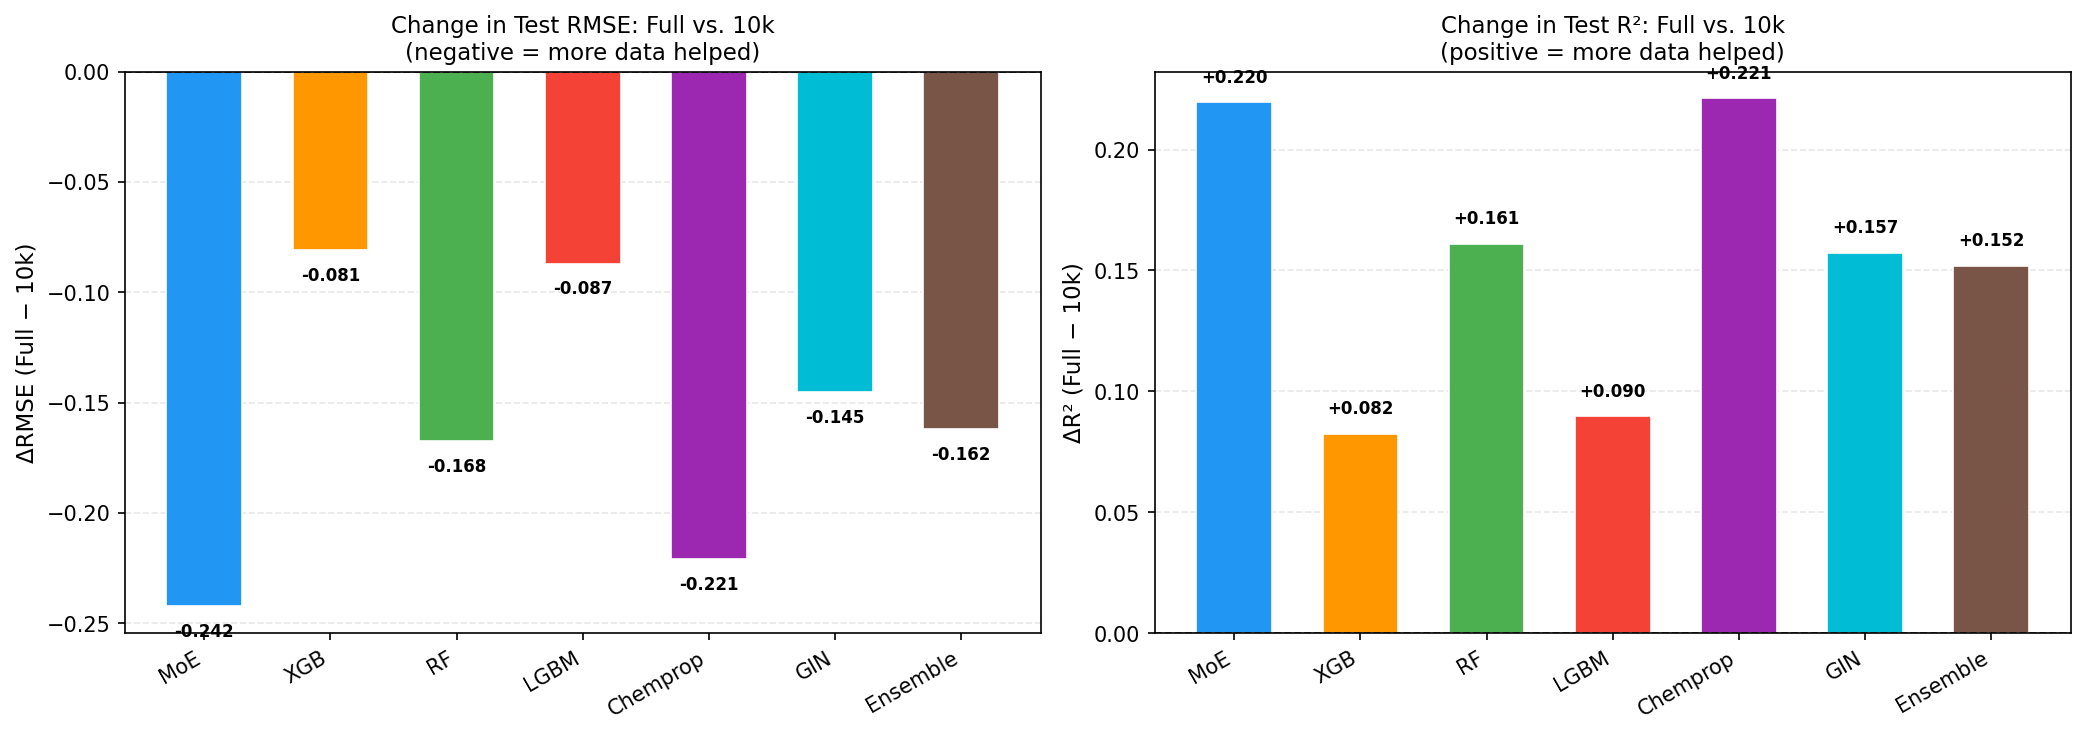

In [3]:
from IPython.display import Image, display
display(Image(filename='runs/production_run/delta_metrics.png'))

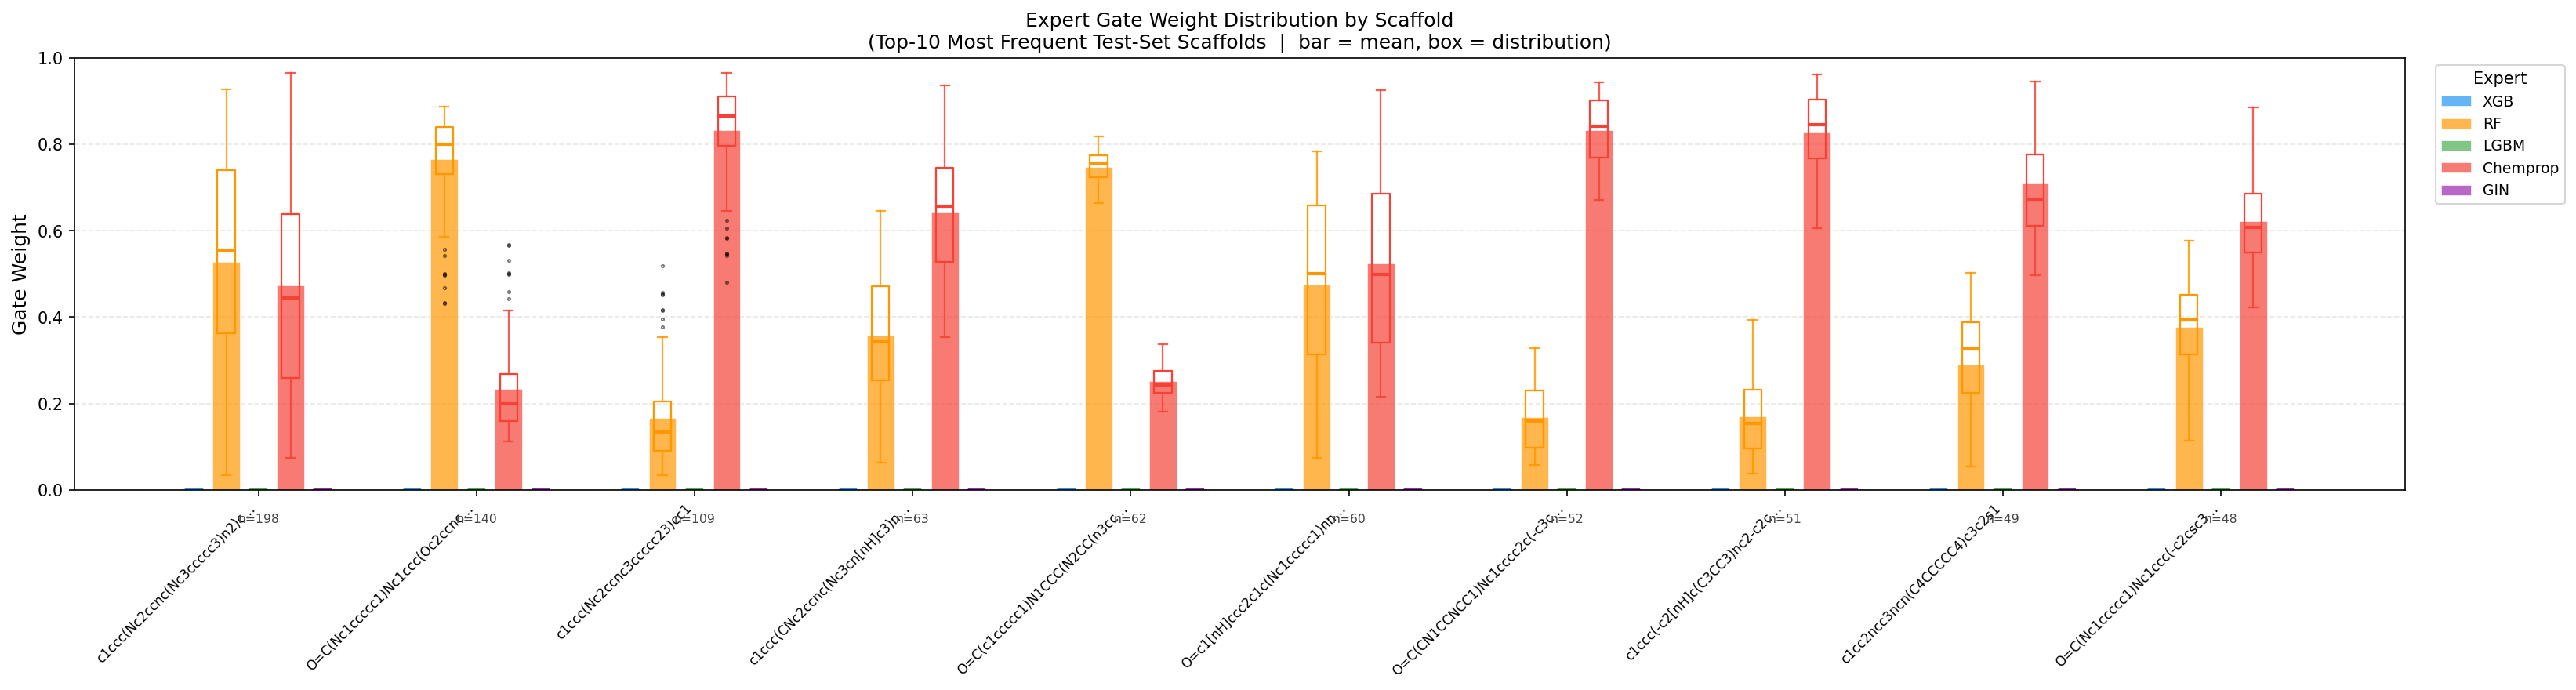

In [4]:
# After training on full data
display(Image(filename='runs/production_run/scaffold_weights.png'))

### Best MoE Configuration
- After hyperparamter search, the following configurations result in the lowest test RMSE for each data regime:
    1. **Low Data (10K):** Soft routing, no entropy regularization, and no load-balancing results in $~0.47$ test $R^2$
    2. **High Data (45K):** Top-2 routing, 10^-4 entropy regularization, and no load-balancing results in $~0.689$ test $R^2$

In [5]:
import json
with open('runs/production_run/best_config.json', 'r') as file:
    data = json.load(file)

json_processed = json.dumps(data, indent=4)
print(json_processed)

{
    "n_low": 10000,
    "n_full": 45484,
    "low_data": {
        "best_config": {
            "n_estimators": 200,
            "learning_rate": 0.05,
            "lgbm_reg_lambda": 0.0,
            "rf_max_features": 1.0,
            "dmpnn_dropout": 0.0,
            "gin_num_layers": 4,
            "weight_decay": 0.01,
            "oracle_reg": 0.0,
            "entropy_reg": 0.0,
            "load_balancing": false,
            "top_k": null
        },
        "val_rmse": 0.8781057318098637,
        "val_r2": 0.5762982883793144,
        "test_metrics": {
            "moe_rmse": 1.0329464753396853,
            "moe_r2": 0.4698459705512089,
            "ensemble_rmse": 1.0235340350388353,
            "ensemble_r2": 0.47946371565998824,
            "xgb_rmse": 1.0644498013854524,
            "xgb_r2": 0.43701502951081705,
            "rf_rmse": 1.0500996852950788,
            "rf_r2": 0.4520921948814366,
            "lgbm_rmse": 1.0800756253601105,
            "lgbm_r2": 0.42036478

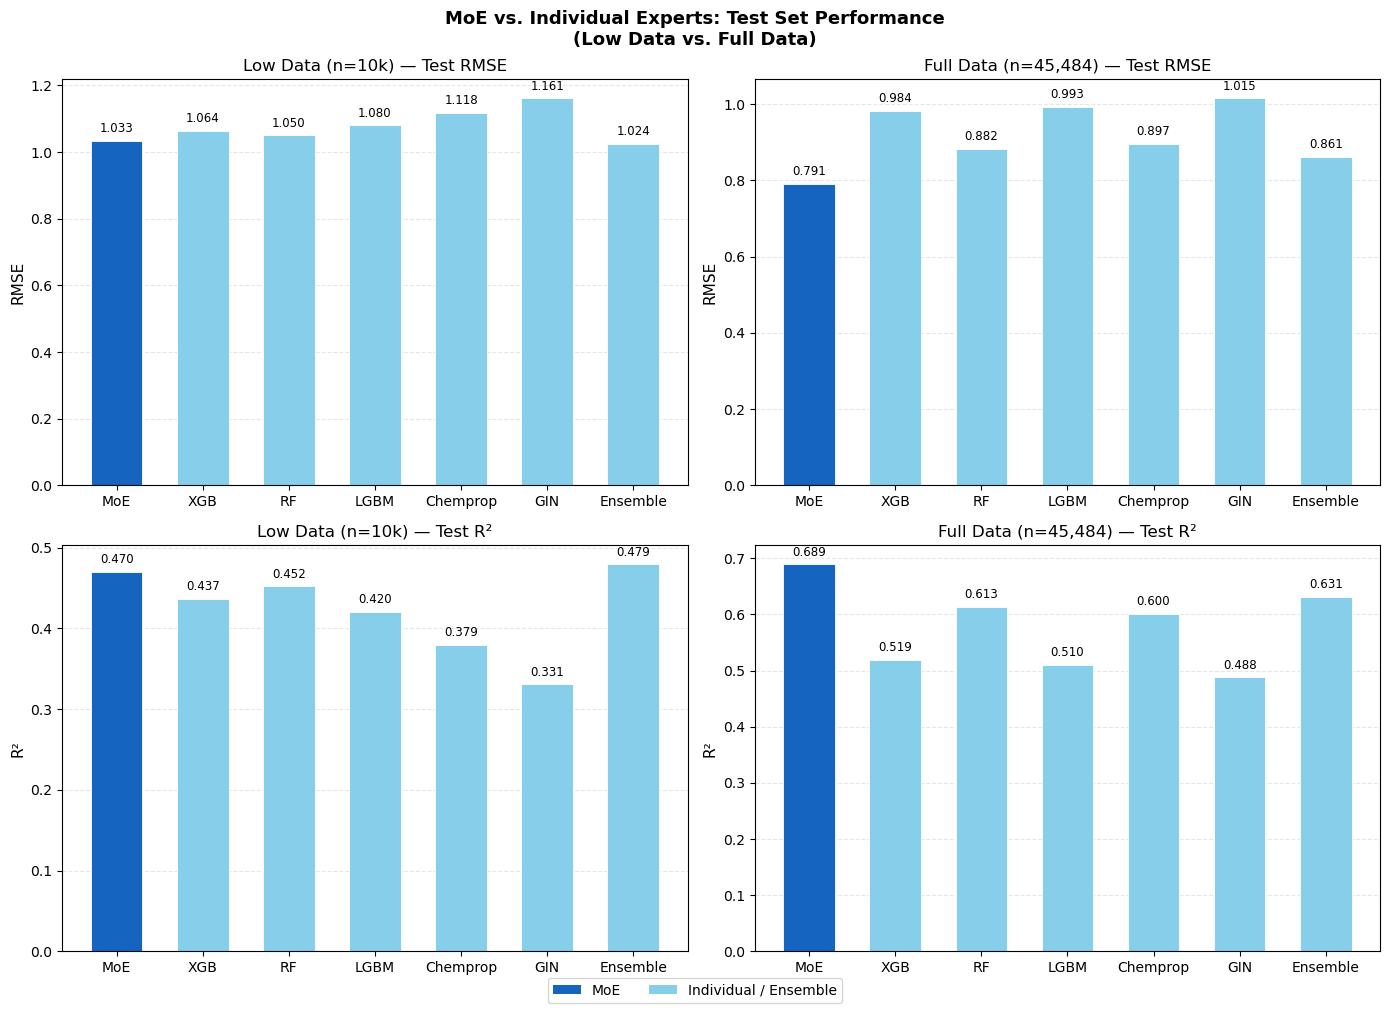

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

with open('runs/production_run/best_config.json') as f:
    cfg = json.load(f)

labels    = ['MoE', 'XGB', 'RF', 'LGBM', 'Chemprop', 'GIN', 'Ensemble']
keys_rmse = ['moe_rmse', 'xgb_rmse', 'rf_rmse', 'lgbm_rmse', 'chemprop_rmse', 'gin_rmse', 'ensemble_rmse']
keys_r2   = ['moe_r2',   'xgb_r2',   'rf_r2',   'lgbm_r2',   'chemprop_r2',   'gin_r2',   'ensemble_r2']

low_rmse  = [cfg['low_data']['test_metrics'][k]  for k in keys_rmse]
low_r2    = [cfg['low_data']['test_metrics'][k]  for k in keys_r2]
full_rmse = [cfg['full_data']['test_metrics'][k] for k in keys_rmse]
full_r2   = [cfg['full_data']['test_metrics'][k] for k in keys_r2]

SKY_BLUE  = '#87CEEB'
DARK_BLUE = '#1565C0'

colors = [DARK_BLUE if i == 0 else SKY_BLUE for i in range(len(labels))]
x      = np.arange(len(labels))

def plot_bar(ax, values, title, ylabel):
    bars = ax.bar(x, values, width=0.6, color=colors, edgecolor='white', linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.yaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    offset = max(abs(v) for v in values) * 0.015
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5
        )

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_bar(axes[0, 0], low_rmse,  f'Low Data (n=10k) — Test RMSE',             'RMSE')
plot_bar(axes[0, 1], full_rmse, f'Full Data (n={cfg["n_full"]:,}) — Test RMSE', 'RMSE')
plot_bar(axes[1, 0], low_r2,    f'Low Data (n=10k) — Test R\u00b2',           'R\u00b2')
plot_bar(axes[1, 1], full_r2,   f'Full Data (n={cfg["n_full"]:,}) — Test R\u00b2', 'R\u00b2')

legend_elements = [
    Patch(facecolor=DARK_BLUE, label='MoE'),
    Patch(facecolor=SKY_BLUE,  label='Individual / Ensemble'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), frameon=True)

fig.suptitle('MoE vs. Individual Experts: Test Set Performance\n(Low Data vs. Full Data)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('runs/production_run/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
